/var/folders/fk/kt7njm6n07x1xlh8lppw23jr0000gp/T/ipykernel_81832/1388128887.py:75: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([results[a] for a in alphas], labels=alphas, showmeans=True, meanline=False)


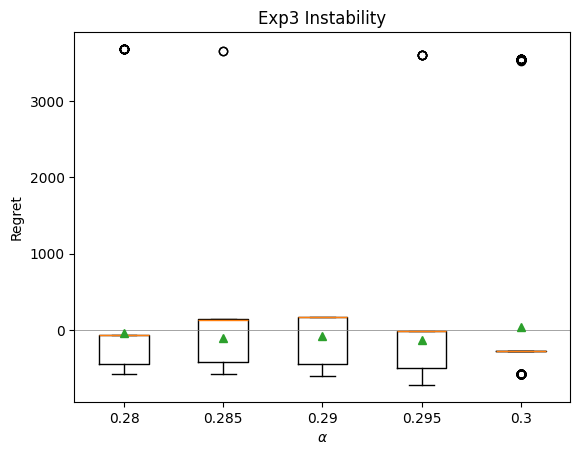

In [1]:
#2.f: 

import jax
import jax.numpy as jnp
import numpy as np
import matplotlib.pyplot as plt

# 1. Define the core logic in a JAX-friendly way
def exp3_simulation(rng_key, alpha, n, eta, K=2):
    half_n = n // 2
    
    # Precompute the sequence of environment losses
    # First half: y = [0, alpha], Second half: y = [1, 0]
    y_first = jnp.zeros((half_n, K)).at[:, 1].set(alpha)
    y_second = jnp.zeros((n - half_n, K)).at[:, 0].set(1.0)
    y_seq = jnp.concatenate([y_first, y_second], axis=0)

    # The step function for jax.lax.scan (runs at each time step t)
    def step(state, y_t):
        weights, key = state
        p = weights / jnp.sum(weights)
        
        # Split key for sampling
        key, subkey = jax.random.split(key)
        
        # Sample arm (JAX's categorical uses logits, log(p) is numerically stable)
        a_t = jax.random.categorical(subkey, jnp.log(p))
        
        # Actual loss accumulated
        loss_t = y_t[a_t]
        
        # Exp3 Loss Estimator & Weight update
        y_hat = jnp.zeros(K).at[a_t].set(y_t[a_t] / p[a_t])
        weights = weights * jnp.exp(-eta * y_hat)
        
        return (weights, key), loss_t

    # Initial state for scan
    init_state = (jnp.ones(K), rng_key)
    
    # Run the loop over all time steps efficiently
    _, losses = jax.lax.scan(step, init_state, y_seq)
    
    # Calculate regret
    total_loss = jnp.sum(losses)
    min_loss = jnp.minimum(half_n, alpha * half_n)
    
    return total_loss - min_loss

# 2. Vectorize across 'm' independent runs and JIT compile!
# in_axes=(0, None, None, None) maps over an array of random keys, keeping other args constant
vmap_exp3 = jax.jit(jax.vmap(exp3_simulation, in_axes=(0, None, None, None)), static_argnums=(2,))

def run_exp3_variance_jax(n=10000, m=500, alphas=[0.28, 0.285, 0.29, 0.295, 0.3]):
    K = 2
    eta = np.sqrt(2 * np.log(K) / (n * K))
    
    # Initialize JAX random key
    base_key = jax.random.PRNGKey(42)
    
    results = {}
    for alpha in alphas:
        # Generate 'm' different random keys for the 'm' parallel simulations
        base_key, subkey = jax.random.split(base_key)
        keys = jax.random.split(subkey, m)
        
        # Execute the JIT-compiled, vectorized function
        # This computes all 500 runs for this alpha instantly
        regrets = vmap_exp3(keys, alpha, n, eta)
        
        # Convert the JAX array back to a standard numpy array for plotting
        results[alpha] = np.array(regrets)

    # Plotting
    plt.boxplot([results[a] for a in alphas], labels=alphas, showmeans=True, meanline=False)
    plt.ylabel('Regret')
    plt.xlabel(r'$\alpha$')
    plt.title('Exp3 Instability')
    plt.axhline(0, color='grey', linewidth=0.5)
    plt.show()

run_exp3_variance_jax()

# Problem 3: Exp3 on stochastic bandits
In this exercise we compare UCB and Exp3 on stochastic data. Suppose we have a two-armed stochastic Bernoulli bandit with $\mu_1 = 0.5$ and $\mu_2 = \mu_1 + \Delta$ with $\Delta = 0.05$.

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from tqdm.auto import tqdm
import jax
import jax.numpy as jnp
from functools import partial

# Plotting style
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['axes.grid'] = True

# Basic pseudo-random number generator (PRNG) key for JAX
base_key = jax.random.PRNGKey(42)

## 1. Algorithms Implementation
We implement the **UCB** algorithm and the **Exp3** algorithm using `jax` and `jax.lax.scan` for rapid parallel hardware execution.

In [3]:
@partial(jax.jit, static_argnums=(2,))
def ucb(key, means, n_rounds):
    """"Runs the UCB algorithm for n_rounds."""
    K = means.shape[0]
    best_mean = jnp.max(means)
    
    def step(carry, t):
        counts, values, key = carry
        key, subkey = jax.random.split(key)
        
        cb = jnp.sqrt(2 * jnp.log(t + 1) / (counts + 1e-10))
        ucb_values = values + cb
        
        # Pull arm t during initialization phase (t < K), otherwise pull max UCB arm
        arm = jnp.where(t < K, t, jnp.argmax(ucb_values))
        
        reward = jax.random.bernoulli(subkey, means[arm]).astype(jnp.float32)
        regret = best_mean - means[arm]
        
        counts = counts.at[arm].add(1)
        n = counts[arm]
        new_val = ((n - 1) / n) * values[arm] + (1 / n) * reward
        values = values.at[arm].set(new_val)
        
        return (counts, values, key), regret
        
    init_carry = (jnp.zeros(K), jnp.zeros(K), key)
    times = jnp.arange(n_rounds)
    _, regrets = jax.lax.scan(step, init_carry, times)
    return jnp.cumsum(regrets)

@partial(jax.jit, static_argnums=(2,))
def exp3(key, means, n_rounds, eta):
    """Runs the Exp3 algorithm for n_rounds with learning rate eta."""
    K = means.shape[0]
    best_mean = jnp.max(means)
    
    def step(carry, t):
        log_weights, key = carry
        
        # Softmax over log weights for numerical stability
        max_lw = jnp.max(log_weights)
        weights = jnp.exp(log_weights - max_lw)
        probs = weights / jnp.sum(weights)
        
        key, subkey1, subkey2 = jax.random.split(key, 3)
        arm = jax.random.choice(subkey1, K, p=probs)
        
        reward = jax.random.bernoulli(subkey2, means[arm]).astype(jnp.float32)
        regret = best_mean - means[arm]
        
        # Importance weighted loss estimation
        loss = 1.0 - reward
        estimated_loss = jnp.zeros(K).at[arm].set(loss / probs[arm])
        log_weights = log_weights - eta * estimated_loss
        
        return (log_weights, key), regret
        
    init_carry = (jnp.zeros(K), key)
    times = jnp.arange(n_rounds)
    _, regrets = jax.lax.scan(step, init_carry, times)
    return jnp.cumsum(regrets)

# Vectorized functions to run multiple trials in parallel
@partial(jax.jit, static_argnums=(2,))
def run_trials_ucb(keys, means, n_rounds):
    return jax.vmap(ucb, in_axes=(0, None, None))(keys, means, n_rounds)

@partial(jax.jit, static_argnums=(2,))
def run_trials_exp3(keys, means, n_rounds, eta):
    return jax.vmap(exp3, in_axes=(0, None, None, None))(keys, means, n_rounds, eta)

## 2. Experiment (a): Regret vs Horizon
(a) Plot the regret of UCB and Exp3 on the same plot as a function of the horizon $n$ using the learning rate equal to $\eta = \sqrt{\frac{2 \log(K)}{nK}}$.

Running  (a)...


Horizon n:   0%|          | 0/7 [00:00<?, ?it/s]

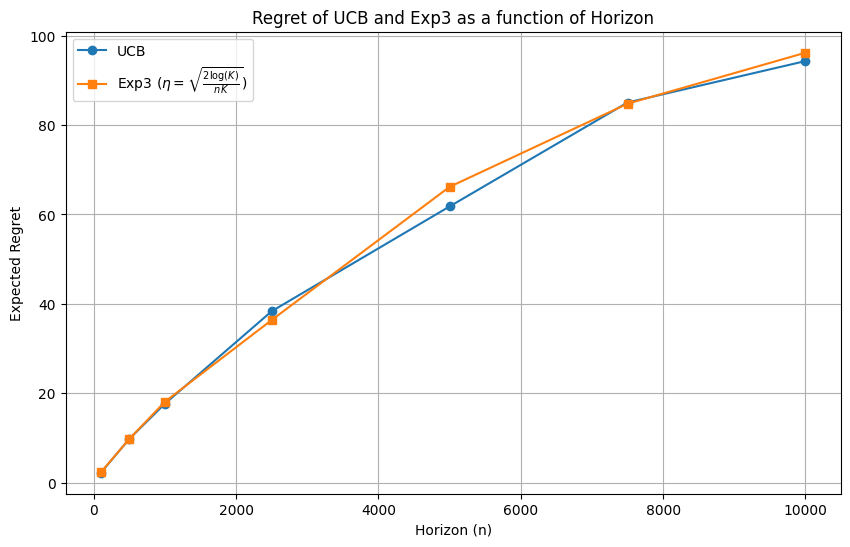

In [4]:
def run_experiment_a():
    global base_key
    mu1 = 0.5
    delta = 0.05
    means = jnp.array([mu1, mu1 + delta])
    K = len(means)
    
    horizons = np.array([100, 500, 1000, 2500, 5000, 7500, 10000])
    n_trials = 100
    
    expected_regret_ucb = np.zeros(len(horizons))
    expected_regret_exp3 = np.zeros(len(horizons))
    
    print("Running  (a)...")
    for i, n in enumerate(tqdm(horizons, desc="Horizon n")):
        eta = np.sqrt(2 * np.log(K) / (n * K))
        
        base_key, subkey = jax.random.split(base_key)
        keys = jax.random.split(subkey, n_trials)
        
        # JAX evaluates all trials efficiently 
        regret_ucb_all = run_trials_ucb(keys, means, n)    # shape (n_trials, n)
        regret_exp3_all = run_trials_exp3(keys, means, n, eta)
        
        expected_regret_ucb[i] = np.mean(regret_ucb_all[:, -1])
        expected_regret_exp3[i] = np.mean(regret_exp3_all[:, -1])
        
    plt.figure()
    plt.plot(horizons, expected_regret_ucb, marker='o', label='UCB')
    plt.plot(horizons, expected_regret_exp3, marker='s', label=r'Exp3 ($\eta = \sqrt{\frac{2\log(K)}{nK}}$)')
    plt.xlabel('Horizon (n)')
    plt.ylabel('Expected Regret')
    plt.title('Regret of UCB and Exp3 as a function of Horizon')
    plt.legend()
    plt.show()

run_experiment_a()

## 3. Experiment (b): Regret vs Learning Rate $\eta$
(b) Now fix the horizon to $n=10^5$ and plot the regret as a function of the learning rate.

Running (b) ...


Learning rate eta:   0%|          | 0/40 [00:00<?, ?it/s]

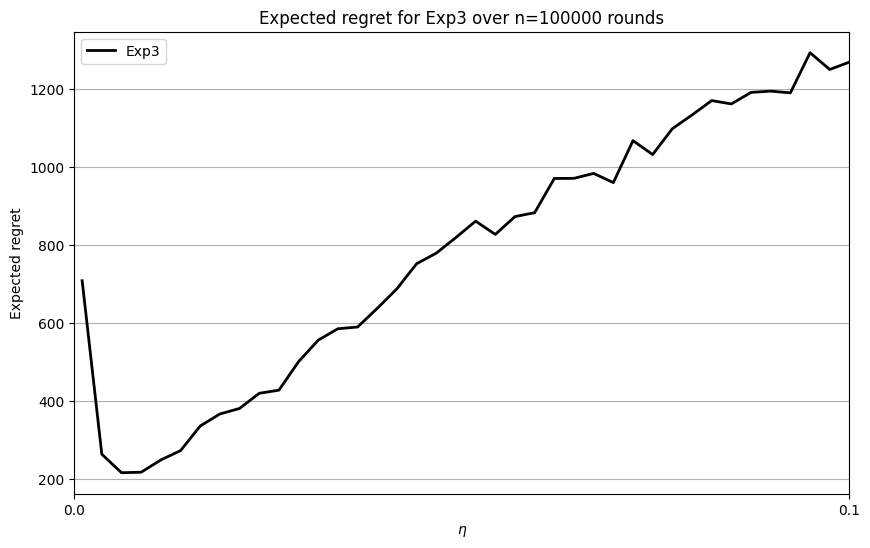

In [5]:
def run_experiment_b(n=100000, n_trials=50):
    global base_key
    mu1 = 0.5
    delta = 0.05
    means = jnp.array([mu1, mu1 + delta])
    
    etas = np.linspace(0.001, 0.1, 40)
    expected_regret_exp3 = np.zeros(len(etas))
    
    print("Running (b) ...")
    
    # Precompile to avoid jitter in progress bar mapping
    base_key, subkey = jax.random.split(base_key)
    trial_keys = jax.random.split(subkey, n_trials)
    _ = run_trials_exp3(trial_keys, means, n, etas[0])
    
    for i, eta in enumerate(tqdm(etas, desc="Learning rate eta")):
        base_key, subkey = jax.random.split(base_key)
        keys = jax.random.split(subkey, n_trials)
        
        regret_all = run_trials_exp3(keys, means, n, eta)
        expected_regret_exp3[i] = np.mean(regret_all[:, -1])
        
    plt.figure()
    plt.plot(etas, expected_regret_exp3, color='black', linewidth=2, label='Exp3')
    plt.xlabel(r'$\eta$')
    plt.ylabel('Expected regret')
    plt.xlim([0, 0.1])
    plt.xticks([0, 0.1])
    plt.legend()
    plt.title(f'Expected regret for Exp3 over n={n} rounds')
    plt.show()
    
    return etas, expected_regret_exp3

etas_b, exp_regret_b = run_experiment_b(n=100000, n_trials=50)

## 4. Experiment (c): Investigating different $\Delta$ gaps
(c) Investigate how the shape of this graph changes as you change $\Delta$.

Running (c) ...


<>:31: SyntaxWarning: invalid escape sequence '\D'
<>:31: SyntaxWarning: invalid escape sequence '\D'
/var/folders/fk/kt7njm6n07x1xlh8lppw23jr0000gp/T/ipykernel_81832/3073135370.py:31: SyntaxWarning: invalid escape sequence '\D'
  plt.title('Shape of Exp3 regret curve for different $\Delta$ gaps')


Delta:   0%|          | 0/5 [00:00<?, ?it/s]

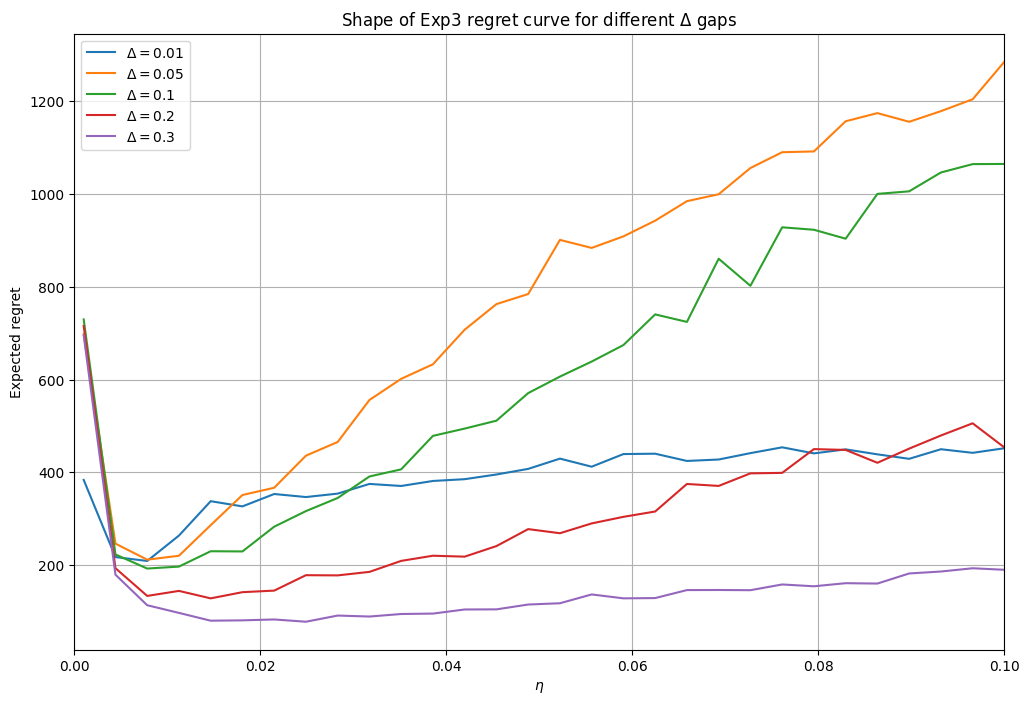

In [6]:
def run_experiment_c(n=100000, n_trials=30):
    global base_key
    mu1 = 0.5
    deltas = [0.01, 0.05, 0.1, 0.2, 0.3]
    etas = np.linspace(0.001, 0.1, 30)
    
    results = {}
    
    print("Running (c) ...")
    plt.figure(figsize=(12, 8))
    
    for delta in tqdm(deltas, desc="Delta"):
        mu2 = min(mu1 + delta, 1.0)
        means = jnp.array([mu1, mu2])
        expected_regret = np.zeros(len(etas))
        
        for i, eta in enumerate(etas):
            base_key, subkey = jax.random.split(base_key)
            keys = jax.random.split(subkey, n_trials)
            
            regret_all = run_trials_exp3(keys, means, n, eta)
            expected_regret[i] = np.mean(regret_all[:, -1])
            
        results[delta] = expected_regret
        plt.plot(etas, expected_regret, label=rf'$\Delta = {delta}$')
        
    plt.xlabel(r'$\eta$')
    plt.ylabel('Expected regret')
    plt.xlim([0, 0.1])
    plt.legend()
    plt.title('Shape of Exp3 regret curve for different $\Delta$ gaps')
    plt.show()
    
    return etas, deltas, results

etas_c, deltas_c, results_c = run_experiment_c(n=100000, n_trials=30)

## 5. Experiment (d): Minimizing Worst-Case Regret
(d) Find empirically the choice of $\eta$ that minimises the worst-case regret over all reasonable choices of $\Delta$, and compare to the value proposed by the theory.

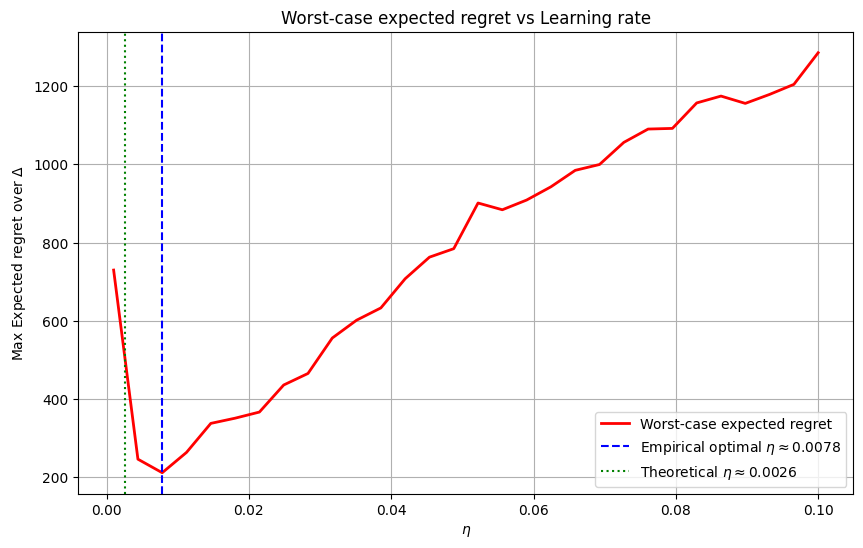

Empirical optimal eta: 0.00783
Theoretical eta      : 0.00263


In [7]:
def run_experiment_d(etas, deltas, results, n=100000):
    regret_matrix = np.array([results[delta] for delta in deltas])
    worst_case_regret = np.max(regret_matrix, axis=0)
    
    optimal_idx = np.argmin(worst_case_regret)
    optimal_eta_emp = etas[optimal_idx]
    
    theoretical_eta = np.sqrt(2 * np.log(2) / (n * 2))
    
    plt.figure()
    plt.plot(etas, worst_case_regret, 'r-', linewidth=2, label='Worst-case expected regret')
    plt.axvline(x=optimal_eta_emp, color='blue', linestyle='--', label=f'Empirical optimal $\\eta\\approx {optimal_eta_emp:.4f}$')
    plt.axvline(x=theoretical_eta, color='green', linestyle=':', label=f'Theoretical $\\eta\\approx {theoretical_eta:.4f}$')
    plt.xlabel(r'$\eta$')
    plt.ylabel(r'Max Expected regret over $\Delta$')
    plt.legend()
    plt.title('Worst-case expected regret vs Learning rate')
    plt.show()
    
    print(f"Empirical optimal eta: {optimal_eta_emp:.5f}")
    print(f"Theoretical eta      : {theoretical_eta:.5f}")

run_experiment_d(etas_c, deltas_c, results_c)

## 6. Conclusion and Story
(e) What can you conclude from all this? Tell an interesting story.

**Conclusion:**
 - Regret vs. Horizon (a): UCB is built for stochastic environments and typically shows $O(\log n)$ regret, whereas Exp3 is designed for adversarial settings with a theoretical $O(\sqrt{n})$ regret. The plot in (a) indicates that up to a horizon of $n=10000$, UCB and a precisely tuned Exp3 ($\eta = \sqrt{\frac{2\log(K)}{nK}}$) have nearly identical, overlapping regret curves. The tuned Exp3 performs comparably to UCB in a stochastic setting over these horizons.
 
 - Tuning $\eta$ (b and c): The learning rate $\eta$ controls the exploration-exploitation trade-off for Exp3. If $\eta$ is too low, the algorithm over-explores and picks arms almost uniformly at random, resulting in high expected regret. If $\eta$ is too high, the algorithm exploits prematurely. In this case, bad luck on optimal arms penalizes them heavily and also leads to high regret. This dynamic creates a visible V or U shape in the curve. Varying $\Delta$ demonstrates that a smaller, harder gap results in a sharper and higher regret valley.Minimax 
 
 - Optimality (d): The theoretically optimal $\eta$ based on mathematical bounds ($\sim 0.0026$) is a defensive value intended for the worst-case adversary. Our empirically derived safest $\eta$ across the tested stochastic gaps ($\sim 0.0078$) is noticeably larger. This indicates that the purely adversarial theoretical bound is slightly too pessimistic in practice. When dealing with stochastic gaps, we can afford a higher learning rate and take a more aggressive approach.